In [2]:
# Cell 1: Imports & Parameter
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itables import init_notebook_mode, show

from utils.parquet_io import load_parquet
# >>> Pfad zu DEINEM Run anpassen:
run_dir = Path(r"C:\Dev\Bachelorarbeit\results\accounting\runs\cpcv_final\icvar_ppo_S0_final\ppo_icvar_state0_cpcv_20251222_143439\E2")
paths = [f"Path_{i:02d}" for i in range(1, 6)]

def load_and_info(path: Path) -> pd.DataFrame:
    """Lädt ein Parquet und gibt Infos aus."""
    df = load_parquet(path)
    print(f"\n--- {path.name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    return df


In [12]:
df_btc = load_and_info(run_dir / "Path_02/trade_events.parquet")
display(df_btc.head(50), df_btc.tail(10))


--- trade_events.parquet ---
Shape: (137, 11)
Columns: 11


,asset,q,adj_open,p_exec,notional_abs,spread_cost,fees,vol_slip,total_cost,round,t
0,BTC-USD,1228.240976,218.039993,218.367053,268207.362619,401.708485,670.518407,0.0,670.518407,20,2015-02-02 00:00:00+00:00
1,BTC-USD,1290.416420,226.929993,227.270388,293273.439992,439.251287,733.183600,0.0,733.183600,21,2015-02-03 00:00:00+00:00
2,BTC-USD,227.910333,226.261749,226.601142,51644.741609,77.351086,129.111854,0.0,129.111854,71,2015-04-16 00:00:00+00:00
3,BTC-USD,-229.565475,265.245117,264.847250,60799.784658,91.336683,151.999462,0.0,151.999462,127,2015-07-07 00:00:00+00:00
4,ETH-USD,303299.870139,1.050000,1.051575,318942.546461,477.697278,797.356366,0.0,797.356366,153,2015-08-12 00:00:00+00:00
5,BTC-USD,218.167781,263.392548,263.787636,57549.963371,86.195652,143.874908,0.0,143.874908,154,2015-08-13 00:00:00+00:00
6,BTC-USD,568.781370,260.143433,260.533648,148186.684993,221.947109,370.466712,0.0,370.466712,155,2015-08-14 00:00:00+00:00
7,BTC-USD,-292.883425,262.380585,261.987014,76731.653962,115.270388,191.829135,0.0,191.829135,157,2015-08-18 00:00:00+00:00
8,BTC-USD,-238.000000,191.300003,191.013053,45461.106625,68.294102,113.652767,0.0,113.652767,158,2015-08-19 00:00:00+00:00
9,ETH-USD,-43987.411003,1.441001,1.438840,63290.842625,95.078883,158.227107,0.0,158.227107,160,2015-08-21 00:00:00+00:00


,asset,q,adj_open,p_exec,notional_abs,spread_cost,fees,vol_slip,total_cost,round,t
127,BTC-USD,13.772345,8209.632812,8221.947262,113235.493523,169.598843,283.088734,0.0,283.088734,778,2018-02-05 00:00:00+00:00
128,BTC-USD,5.988432,3831.983643,3837.731618,22981.995904,34.421362,57.454990,0.0,57.454990,983,2018-11-27 00:00:00+00:00
129,IEUR,91.000000,35.910500,35.968959,3273.175295,5.319834,8.182938,0.0,8.182938,1026,2019-01-31 00:00:00+00:00
130,BTC-USD,87.123147,3437.882080,3443.038903,299968.385104,449.278664,749.920963,0.0,749.920963,1027,2019-02-01 00:00:00+00:00
131,BTC-USD,86.702221,3456.762695,3461.947839,300158.566839,449.563509,750.396417,0.0,750.396417,1028,2019-02-04 00:00:00+00:00
132,BTC-USD,21.643516,3458.885742,3464.074071,74974.741633,112.293673,187.436854,0.0,187.436854,1029,2019-02-05 00:00:00+00:00
133,BTC-USD,31.222297,9510.007812,9524.272824,297369.678927,445.386443,743.424197,0.0,743.424197,1278,2020-01-31 00:00:00+00:00
134,BTC-USD,31.911125,9332.316406,9346.314881,298251.426152,446.707082,745.628565,0.0,745.628565,1279,2020-02-03 00:00:00+00:00
135,BTC-USD,31.974691,9290.838867,9304.775126,297517.306572,445.607552,743.793266,0.0,743.793266,1280,2020-02-04 00:00:00+00:00
136,BTC-USD,8.624949,9191.731445,9205.519043,79397.133448,118.917325,198.492834,0.0,198.492834,1281,2020-02-05 00:00:00+00:00


In [4]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:
    print(pid)
    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["reward_t","rewards","rwd","step_reward"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


Path_01
Path_02
Path_03
Path_04
Path_05


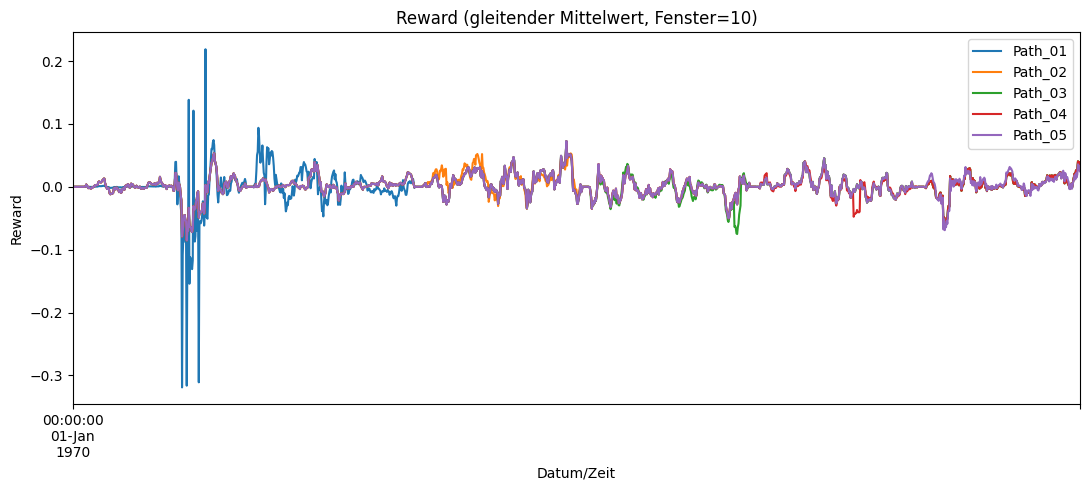

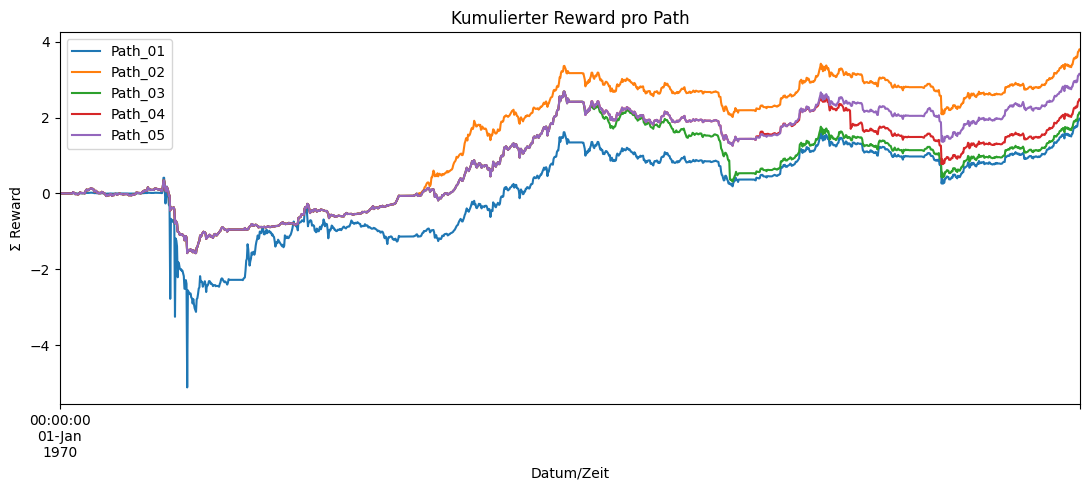

In [5]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("Reward (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Reward")
plt.tight_layout(); plt.show()

# Kumuliert:
wide_cum = wide.fillna(0).cumsum()
ax = wide_cum.plot(figsize=(11,5))
ax.set_title("Kumulierter Reward pro Path")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Σ Reward")
plt.tight_layout(); plt.show()


In [6]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:

    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["nav_t"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


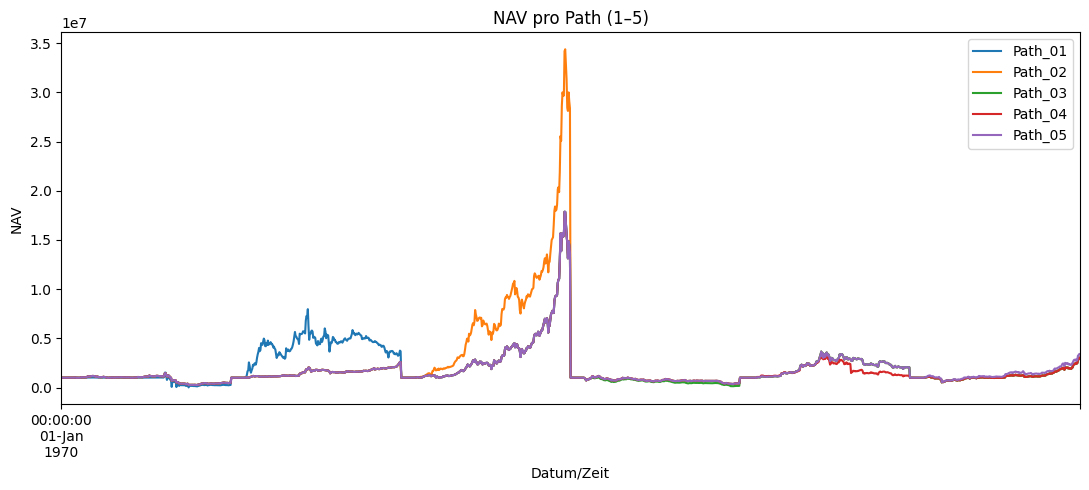

In [7]:
# Cell 3: Plot – Reward pro Path (roh)
ax = wide.plot(figsize=(11,5))
ax.set_title("NAV pro Path (1–5)")
ax.set_xlabel("Datum/Zeit")
ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()

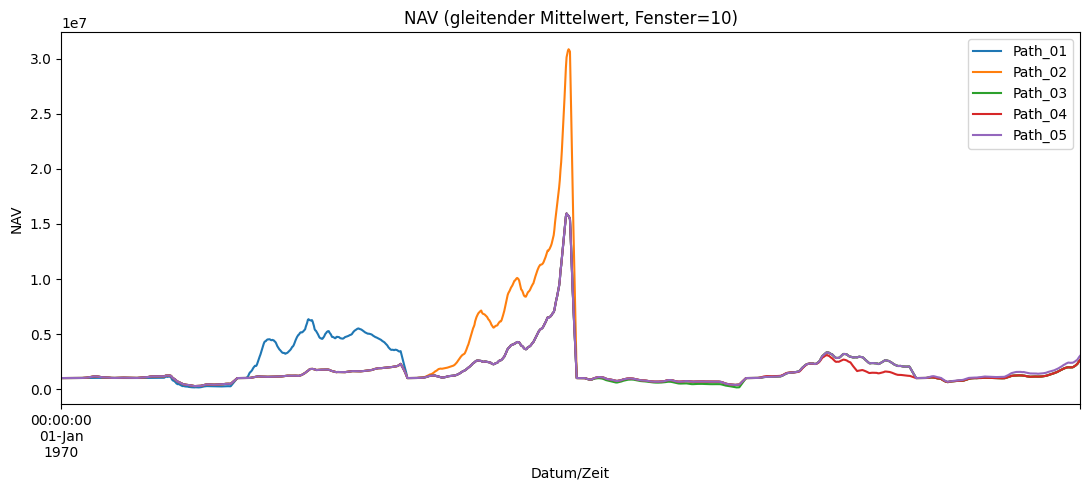

In [8]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("NAV (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()


In [17]:
df_btc = load_and_info(run_dir / "Path_02/portfolio_snapshots.parquet")
display(df_btc.head(192), df_btc.tail(10))


--- portfolio_snapshots.parquet ---
Shape: (1511, 9)
Columns: 9


,round,t,asset,p_close_t,shares,weight_post_t,cash,portfolio_value_t,fees_total_round
0,0,2015-01-02 00:00:00+00:00,SPY,171.414444,0.00000,0.000000,1.000000e+06,1.000000e+06,0.000000
1,1,2015-01-05 00:00:00+00:00,ETH-USD,NaN,0.00000,0.000000,1.000001e+06,1.000001e+06,0.000000
2,2,2015-01-06 00:00:00+00:00,SPY,166.733353,0.00000,0.000000,1.000002e+06,1.000002e+06,0.000000
3,3,2015-01-07 00:00:00+00:00,BTC-USD,NaN,0.00000,0.000000,1.000003e+06,1.000003e+06,0.000000
4,4,2015-01-08 00:00:00+00:00,SPY,171.806625,0.00000,0.000000,1.000003e+06,1.000003e+06,0.000000
...,...,...,...,...,...,...,...,...,...
187,187,2015-09-30 00:00:00+00:00,ETH-USD,0.740000,223625.58814,0.425577,3.358099e+02,3.888438e+05,125.605404
188,188,2015-10-01 00:00:00+00:00,EWC,18.541601,0.00000,0.000000,2.826536e+03,3.755787e+05,120.366749
189,189,2015-10-02 00:00:00+00:00,SPY,165.098587,68.00000,0.045053,9.037684e+03,2.491879e+05,15.566788
190,190,2015-10-05 00:00:00+00:00,ETH-USD,0.642939,0.00000,0.000000,6.541771e+04,2.707231e+05,141.303278


,round,t,asset,p_close_t,shares,weight_post_t,cash,portfolio_value_t,fees_total_round
1501,1501,2020-12-17 00:00:00+00:00,ETH-USD,642.592102,0.000000,0.000000,22670.864859,2.391948e+06,0.0
1502,1502,2020-12-18 00:00:00+00:00,SPY,346.504150,0.000000,0.000000,22670.915238,2.420987e+06,0.0
1503,1503,2020-12-21 00:00:00+00:00,ETH-USD,607.687622,0.000000,0.000000,22670.971916,2.383106e+06,0.0
1504,1504,2020-12-22 00:00:00+00:00,SPY,344.683319,0.000000,0.000000,22671.028593,2.496208e+06,0.0
1505,1505,2020-12-23 00:00:00+00:00,ETH-USD,584.314636,0.000000,0.000000,22671.085271,2.434429e+06,0.0
1506,1506,2020-12-24 00:00:00+00:00,SPY,346.335205,0.000000,0.000000,22671.141948,2.483910e+06,0.0
1507,1507,2020-12-28 00:00:00+00:00,ETH-USD,730.229553,0.000000,0.000000,22671.211221,2.834356e+06,0.0
1508,1508,2020-12-29 00:00:00+00:00,SPY,348.644104,0.000000,0.000000,22671.274197,2.865945e+06,0.0
1509,1509,2020-12-30 00:00:00+00:00,ETH-USD,752.260376,0.000000,0.000000,22671.324577,3.021960e+06,0.0
1510,1510,2020-12-31 00:00:00+00:00,BTC-USD,28975.353516,103.733063,0.991366,22671.381256,3.031881e+06,0.0
